# Cosmos 3 Nano — Full Checkpoint Analysis and Old-Notebook Comparison

This executed report analyses **all 1,748 successful checkpoint records currently stored on GitHub** and compares them with the earlier `cosmos3_mmad_combined_analysis.ipynb` snapshot.

Important scope notes:

- Full MMAD contains **39,670 questions**; this remains a partial benchmark.
- The latest session was configured for **6.0014 hours**, despite the intended 24-hour run.
- GitHub stores successful rows only. The latest log separately reports **397 successful outputs and 12 parse failures from 409 attempts**.
- NVIDIA Build and the community BNB8 Kaggle checkpoint are different execution backends; backend-level results must remain separate.


In [1]:
from pathlib import Path
import json, math, re, warnings
from collections import Counter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', context='notebook')
pd.set_option('display.max_columns', 100)

ROOT = Path.cwd()
search_roots = [ROOT, *ROOT.parents]
candidates = []
for base in search_roots:
    candidates += list(base.glob('research/mmad_model_benchmark/outputs/cosmos3_checkpoint_full/predictions_all_checkpoints.jsonl'))
    candidates += list(base.glob('outputs/cosmos3_checkpoint_full/predictions_all_checkpoints.jsonl'))
PRED = next(p for p in candidates if p.exists())
AUDIT = json.loads((PRED.parent / 'checkpoint_audit.json').read_text(encoding='utf-8'))
rows = [json.loads(x) for x in PRED.read_text(encoding='utf-8').splitlines() if x.strip()]
df = pd.json_normalize(rows, sep='.')
df['reasoning'] = df.reasoning.fillna('')
df['response'] = df.response.fillna('')
df['reasoning_chars'] = df.reasoning.str.len()
df['reasoning_words'] = df.reasoning.str.findall(r"\b[\w'-]+\b").str.len()
df['correct'] = df.correct.astype(bool)
df['answer_bias'] = df.prediction
print('Data:', PRED)
print('Rows:', len(df), '| unique sample IDs:', df.sample_id.nunique())
display(pd.Series(AUDIT, name='value').to_frame())
assert df.sample_id.is_unique
assert len(df) == AUDIT['successful_checkpoint_rows']


Data: C:\Users\ASUS\OneDrive\Desktop\Jarvis-Vision\research\mmad_model_benchmark\outputs\cosmos3_checkpoint_full\predictions_all_checkpoints.jsonl
Rows: 1748 | unique sample IDs: 1748


,value
manifest_sha256,ff6bf9547135bb9b58dcafcbfafb73e0cfbf804edea0b6...
full_benchmark_questions,39670
successful_checkpoint_rows,1748
old_notebook_answered_ids,601
new_successful_ids_since_old_notebook,1147
shards_by_run,"{'Kaggle initial run': 8, 'Kaggle previous run..."
known_latest_run_attempts,409
known_latest_run_successes,397
known_latest_run_parse_failures,12
latest_run_actual_hours,6.0014


## 1. Metrics helpers

In [2]:
def wilson(k, n, z=1.96):
    if n == 0: return np.nan, np.nan
    p=k/n; den=1+z*z/n
    center=(p+z*z/(2*n))/den
    half=z*np.sqrt((p*(1-p)+z*z/(4*n))/n)/den
    return center-half, center+half

def summarize(frame, key):
    out=[]
    for name,g in frame.groupby(key, dropna=False):
        k=int(g.correct.sum()); n=len(g); lo,hi=wilson(k,n)
        out.append({key:name,'n':n,'correct':k,'accuracy':k/n,'ci_low':lo,'ci_high':hi,
                    'median_latency_s':g.latency_seconds.median(),
                    'median_reasoning_chars':g.reasoning_chars.median()})
    return pd.DataFrame(out)


## 2. Checkpoint integrity and run comparison

Successful coverage of full MMAD: 4.41%


,run,n,correct,accuracy,ci_low,ci_high,median_latency_s,median_reasoning_chars
0,Kaggle initial run,380,278,73.2%,68.5%,77.4%,47.229450,879.500000
1,Kaggle latest run (6h),397,291,73.3%,68.7%,77.4%,46.525500,914.000000
2,Kaggle previous run,750,570,76.0%,72.8%,78.9%,44.364900,906.000000
3,NVIDIA Build seed,221,110,49.8%,43.2%,56.3%,8.182000,1259.000000


,snapshot,n,correct,accuracy,ci_low,ci_high,median_latency_s,median_reasoning_chars
0,Added after old notebook,1147,861,75.1%,72.5%,77.5%,45.138500,909.000000
1,Already in old notebook,601,388,64.6%,60.7%,68.3%,42.338400,993.000000


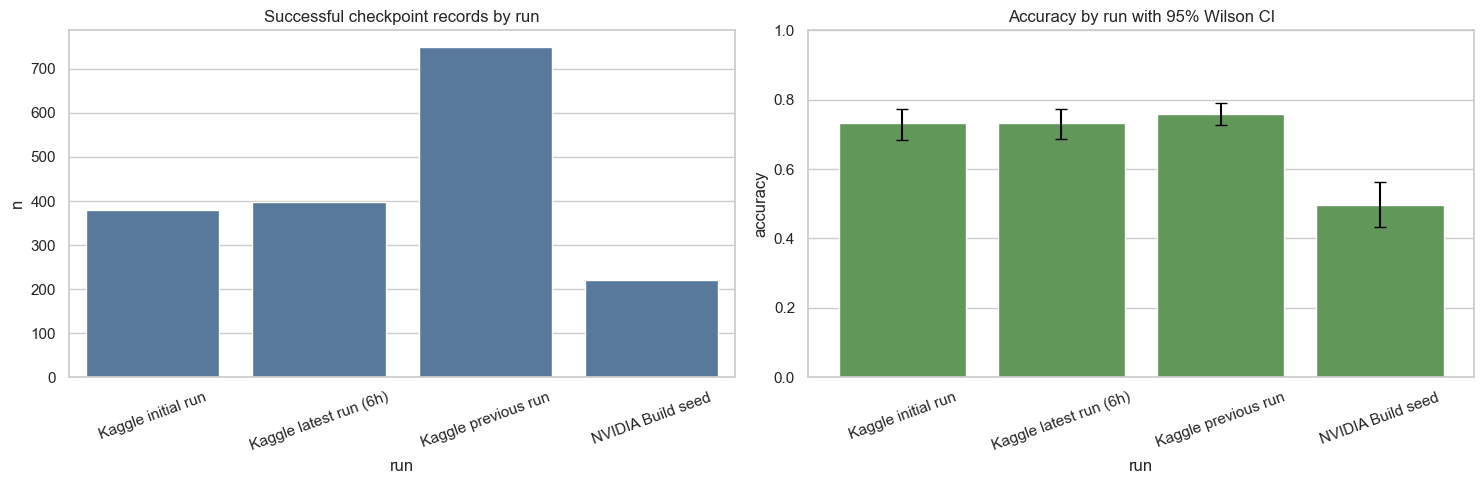

In [3]:
print('Successful coverage of full MMAD: {:.2%}'.format(len(df)/AUDIT['full_benchmark_questions']))
run_summary=summarize(df,'run').sort_values('run')
snapshot_summary=summarize(df,'snapshot').sort_values('snapshot')
display(run_summary.style.format({c:'{:.1%}' for c in ['accuracy','ci_low','ci_high']}))
display(snapshot_summary.style.format({c:'{:.1%}' for c in ['accuracy','ci_low','ci_high']}))

fig,axes=plt.subplots(1,2,figsize=(15,5))
sns.barplot(data=run_summary,x='run',y='n',ax=axes[0],color='#4C78A8')
axes[0].set_title('Successful checkpoint records by run'); axes[0].tick_params(axis='x',rotation=20)
sns.barplot(data=run_summary,x='run',y='accuracy',ax=axes[1],color='#59A14F')
axes[1].errorbar(np.arange(len(run_summary)),run_summary.accuracy,
                 yerr=[run_summary.accuracy-run_summary.ci_low,run_summary.ci_high-run_summary.accuracy],
                 fmt='none',color='black',capsize=4)
axes[1].set_ylim(0,1); axes[1].set_title('Accuracy by run with 95% Wilson CI'); axes[1].tick_params(axis='x',rotation=20)
plt.tight_layout(); plt.show()


## 3. Old notebook vs newly added samples

,snapshot,question_type,n,accuracy
0,Added after old notebook,Anomaly Detection,234,0.405983
7,Already in old notebook,Anomaly Detection,300,0.470000
1,Added after old notebook,Defect Analysis,180,0.922222
8,Already in old notebook,Defect Analysis,53,0.849057
2,Added after old notebook,Defect Classification,180,0.650000
9,Already in old notebook,Defect Classification,48,0.604167
3,Added after old notebook,Defect Description,185,0.837838
10,Already in old notebook,Defect Description,54,0.759259
4,Added after old notebook,Defect Localization,187,0.807487
11,Already in old notebook,Defect Localization,56,0.821429


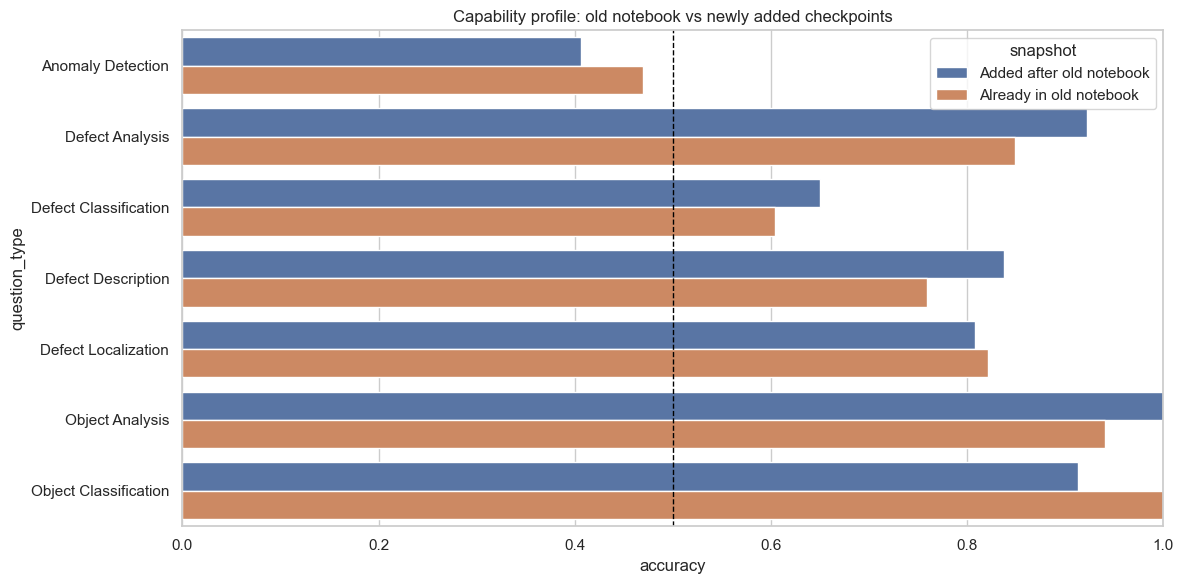

snapshot,Added after old notebook,Already in old notebook
question_type,,
Anomaly Detection,234,300
Defect Analysis,180,53
Defect Classification,180,48
Defect Description,185,54
Defect Localization,187,56
Object Analysis,135,67
Object Classification,46,23


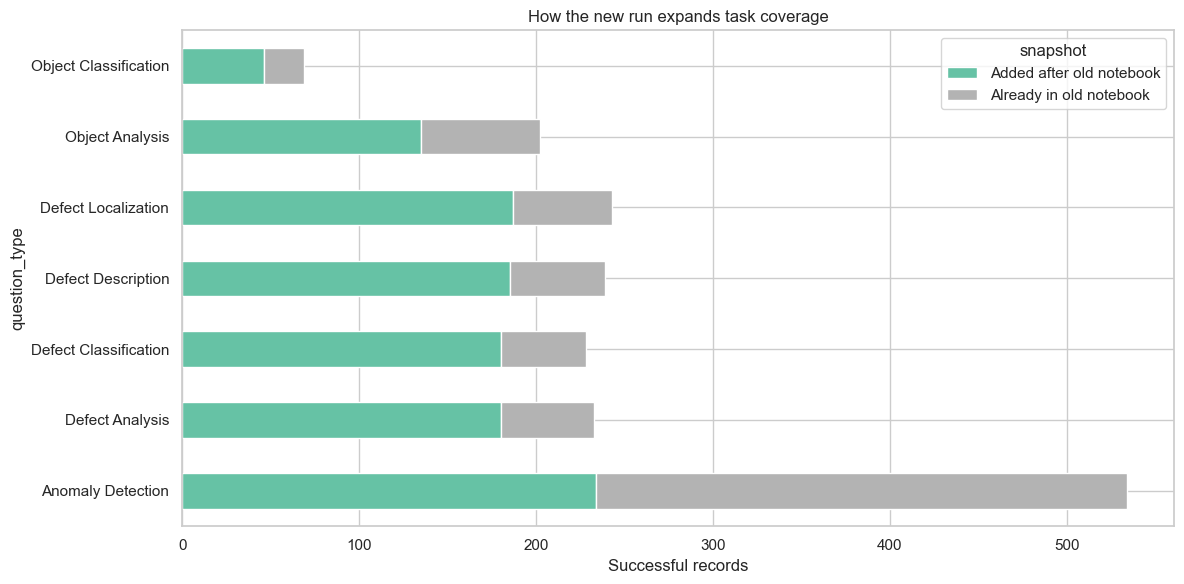

In [4]:
old_new_task=df.groupby(['snapshot','question_type']).agg(n=('sample_id','size'),accuracy=('correct','mean')).reset_index()
display(old_new_task.sort_values(['question_type','snapshot']))
fig,ax=plt.subplots(figsize=(12,6))
sns.barplot(data=old_new_task,y='question_type',x='accuracy',hue='snapshot',ax=ax)
ax.set_xlim(0,1); ax.axvline(.5,color='black',ls='--',lw=1)
ax.set_title('Capability profile: old notebook vs newly added checkpoints')
plt.tight_layout(); plt.show()

coverage=pd.crosstab(df.question_type,df.snapshot)
display(coverage)
coverage.plot(kind='barh',stacked=True,figsize=(12,6),colormap='Set2')
plt.title('How the new run expands task coverage'); plt.xlabel('Successful records'); plt.tight_layout(); plt.show()


## 4. Capability and source analysis

,question_type,n,correct,accuracy,ci_low,ci_high,median_latency_s,median_reasoning_chars
0,Anomaly Detection,534,236,44.2%,40.0%,48.4%,36.615550,954.000000
2,Defect Classification,228,146,64.0%,57.6%,70.0%,47.931550,938.500000
4,Defect Localization,243,197,81.1%,75.7%,85.5%,40.709500,797.000000
3,Defect Description,239,196,82.0%,76.6%,86.4%,42.903100,827.000000
1,Defect Analysis,233,211,90.6%,86.1%,93.7%,59.424600,1176.000000
6,Object Classification,69,65,94.2%,86.0%,97.7%,52.269900,1113.000000
5,Object Analysis,202,198,98.0%,95.0%,99.2%,48.735800,990.500000


,source_dataset,n,correct,accuracy,ci_low,ci_high,median_latency_s,median_reasoning_chars
0,MVTec-AD,1748,1249,71.5%,69.3%,73.5%,44.320350,936.500000


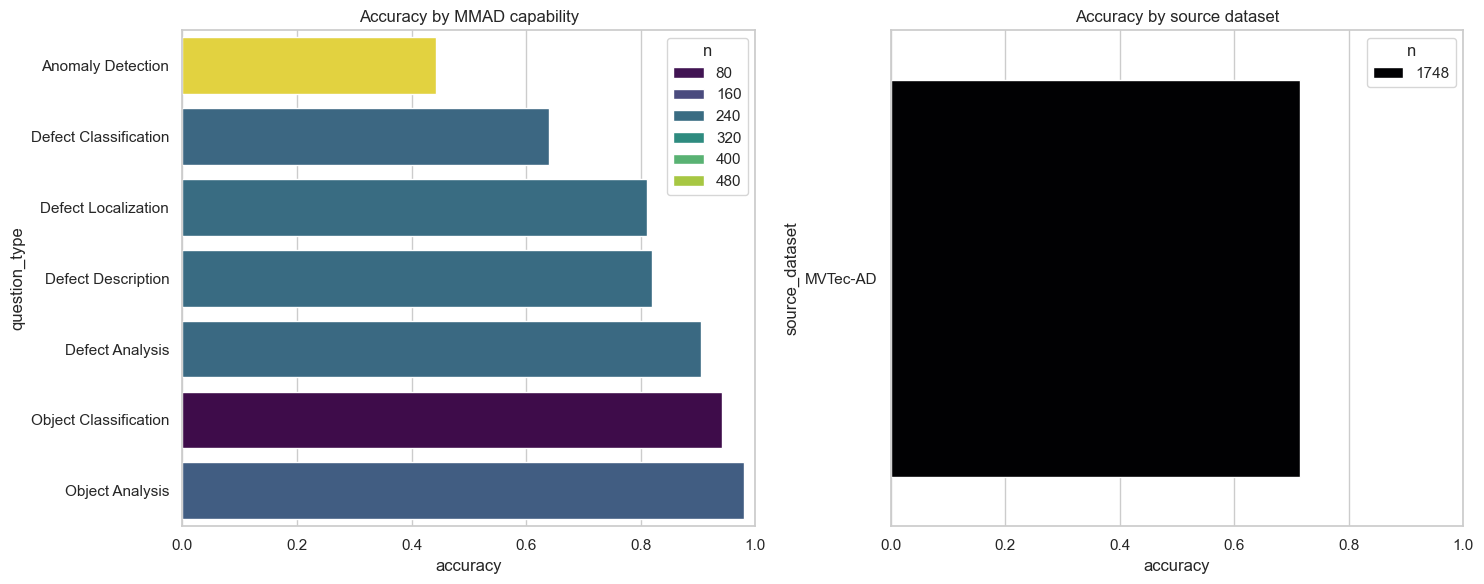

In [5]:
task=summarize(df,'question_type').sort_values('accuracy')
source=summarize(df,'source_dataset').sort_values('accuracy')
display(task.style.format({c:'{:.1%}' for c in ['accuracy','ci_low','ci_high']}))
display(source.style.format({c:'{:.1%}' for c in ['accuracy','ci_low','ci_high']}))

fig,axes=plt.subplots(1,2,figsize=(15,6))
sns.barplot(data=task,y='question_type',x='accuracy',hue='n',palette='viridis',ax=axes[0])
axes[0].set_xlim(0,1); axes[0].set_title('Accuracy by MMAD capability')
sns.barplot(data=source,y='source_dataset',x='accuracy',hue='n',palette='magma',ax=axes[1])
axes[1].set_xlim(0,1); axes[1].set_title('Accuracy by source dataset')
plt.tight_layout(); plt.show()


## 5. Anomaly-detection failure analysis

,Predicted anomaly,Predicted normal
Actual anomaly,94,296
Actual normal,2,142


,TP,FP,TN,FN,precision,recall,F1,miss_rate,overkill_rate
0,94,2,142,296,97.9%,24.1%,38.7%,75.9%,1.4%


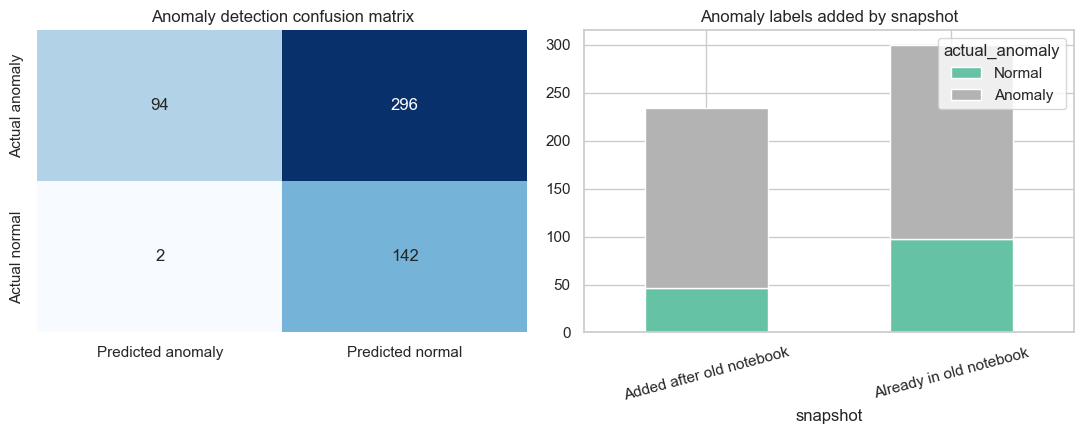

In [6]:
anom=df[df.question_type.eq('Anomaly Detection')].copy()
# MMAD randomizes option letters, so decode semantic Yes/No from the manifest.
anom['actual_anomaly'] = ~anom.is_normal.astype(bool)
anom['predicted_anomaly'] = anom.prediction_text.str.strip().str.lower().str.startswith('yes')
cm=pd.crosstab(anom.actual_anomaly,anom.predicted_anomaly).reindex(index=[True,False],columns=[True,False],fill_value=0)
cm.index=['Actual anomaly','Actual normal']; cm.columns=['Predicted anomaly','Predicted normal']
tp=cm.loc['Actual anomaly','Predicted anomaly']; fn=cm.loc['Actual anomaly','Predicted normal']
fp=cm.loc['Actual normal','Predicted anomaly']; tn=cm.loc['Actual normal','Predicted normal']
precision=tp/(tp+fp) if tp+fp else np.nan
recall=tp/(tp+fn) if tp+fn else np.nan
f1=2*precision*recall/(precision+recall) if precision+recall else np.nan
display(cm)
display(pd.DataFrame([{'TP':tp,'FP':fp,'TN':tn,'FN':fn,'precision':precision,'recall':recall,
                       'F1':f1,'miss_rate':fn/(tp+fn),'overkill_rate':fp/(fp+tn)}]).style.format({
    'precision':'{:.1%}','recall':'{:.1%}','F1':'{:.1%}','miss_rate':'{:.1%}','overkill_rate':'{:.1%}'}))
fig,axes=plt.subplots(1,2,figsize=(11,4.5))
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues',cbar=False,ax=axes[0]); axes[0].set_title('Anomaly detection confusion matrix')
pd.crosstab(anom.snapshot,anom.actual_anomaly).rename(columns={False:'Normal',True:'Anomaly'}).plot(kind='bar',stacked=True,ax=axes[1],colormap='Set2')
axes[1].set_title('Anomaly labels added by snapshot'); axes[1].tick_params(axis='x',rotation=15)
plt.tight_layout(); plt.show()


## 6. Reasoning-content analysis

,correct,n,median_chars,mean_chars,median_words,median_latency_s,uncertainty_rate,defect_term_rate,negation_rate,answer_phrase_rate
0,False,499,924.000000,950.362725,159.000000,41.534500,50.5%,90.6%,79.2%,91.4%
1,True,1249,939.000000,1000.105685,165.000000,45.511500,49.6%,80.4%,75.4%,96.1%


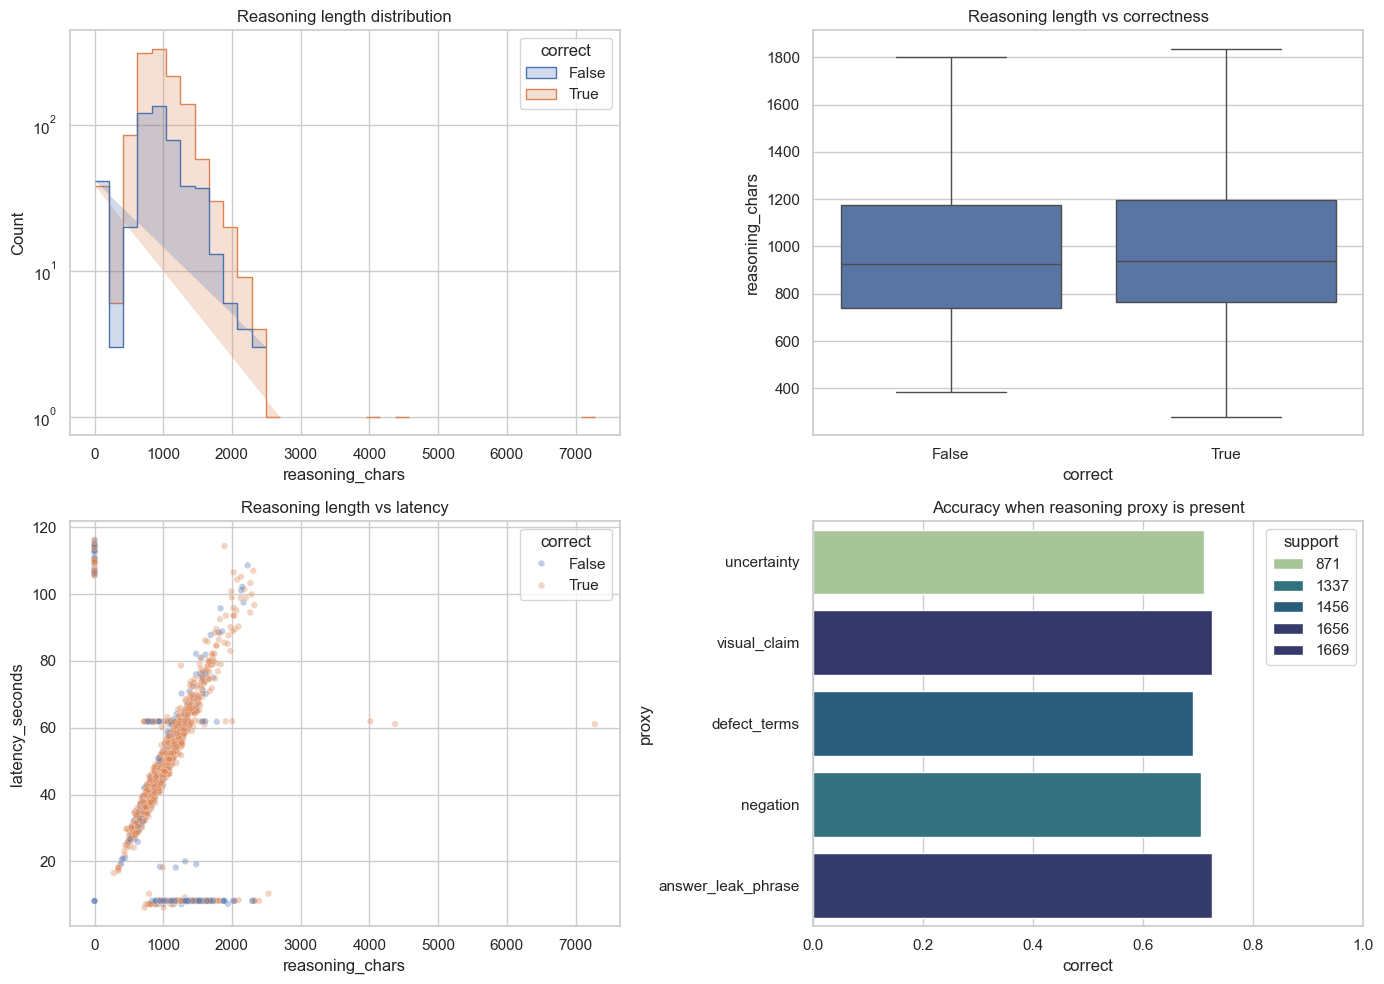

Correlation reasoning chars vs latency: 0.003
Correlation reasoning chars vs correctness: 0.051


In [7]:
patterns={
 'uncertainty':r'\b(maybe|might|could|appears|seems|likely|possibly|unclear)\b',
 'visual_claim':r'\b(image|visible|shown|see|surface|object)\b',
 'defect_terms':r'\b(defect|crack|scratch|dent|damage|anomal|broken|missing|irregular)\w*\b',
 'negation':r'\b(no|not|none|without|lack|absence)\b',
 'answer_leak_phrase':r'\b(answer|option|therefore|correct choice)\b',
}
for name,pat in patterns.items():
    df[name]=df.reasoning.str.contains(pat,case=False,regex=True)

reason_summary=df.groupby('correct').agg(
 n=('sample_id','size'),median_chars=('reasoning_chars','median'),mean_chars=('reasoning_chars','mean'),
 median_words=('reasoning_words','median'),median_latency_s=('latency_seconds','median'),
 uncertainty_rate=('uncertainty','mean'),defect_term_rate=('defect_terms','mean'),
 negation_rate=('negation','mean'),answer_phrase_rate=('answer_leak_phrase','mean')).reset_index()
display(reason_summary.style.format({c:'{:.1%}' for c in ['uncertainty_rate','defect_term_rate','negation_rate','answer_phrase_rate']}))

fig,axes=plt.subplots(2,2,figsize=(14,10))
sns.histplot(data=df,x='reasoning_chars',hue='correct',bins=35,element='step',log_scale=(False,True),ax=axes[0,0])
axes[0,0].set_title('Reasoning length distribution')
sns.boxplot(data=df,x='correct',y='reasoning_chars',showfliers=False,ax=axes[0,1]); axes[0,1].set_title('Reasoning length vs correctness')
sns.scatterplot(data=df,x='reasoning_chars',y='latency_seconds',hue='correct',alpha=.35,s=22,ax=axes[1,0])
axes[1,0].set_title('Reasoning length vs latency')
proxy=pd.DataFrame({'proxy':list(patterns),'correct':[df.loc[df[p],'correct'].mean() for p in patterns],
                    'incorrect':[1-df.loc[df[p],'correct'].mean() for p in patterns],
                    'support':[int(df[p].sum()) for p in patterns]})
sns.barplot(data=proxy,y='proxy',x='correct',hue='support',palette='crest',ax=axes[1,1]); axes[1,1].set_xlim(0,1)
axes[1,1].set_title('Accuracy when reasoning proxy is present')
plt.tight_layout(); plt.show()

print('Correlation reasoning chars vs latency:', round(df.reasoning_chars.corr(df.latency_seconds),3))
print('Correlation reasoning chars vs correctness:', round(df.reasoning_chars.corr(df.correct.astype(int)),3))


## 7. Answer bias

**Prediction distribution**

prediction,A,B,C,D
run,,,,
Kaggle initial run,31.6%,29.5%,21.8%,17.1%
Kaggle latest run (6h),33.8%,27.5%,19.6%,19.1%
Kaggle previous run,28.8%,30.5%,19.7%,20.9%
NVIDIA Build seed,55.2%,44.8%,0.0%,0.0%


**Ground-truth distribution**

ground_truth,A,B,C,D
run,,,,
Kaggle initial run,35.5%,24.5%,22.1%,17.9%
Kaggle latest run (6h),31.2%,30.0%,18.9%,19.9%
Kaggle previous run,30.3%,31.5%,18.9%,19.3%
NVIDIA Build seed,51.1%,48.9%,0.0%,0.0%


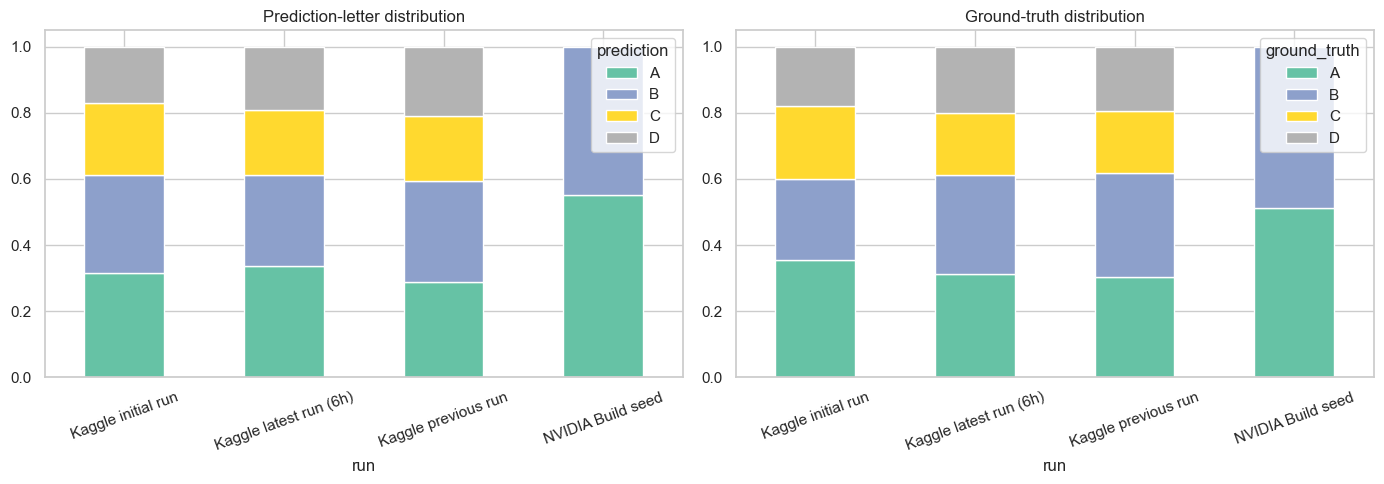

In [8]:
pred_dist=pd.crosstab(df.run,df.prediction,normalize='index').reindex(columns=list('ABCD'),fill_value=0)
truth_dist=pd.crosstab(df.run,df.ground_truth,normalize='index').reindex(columns=list('ABCD'),fill_value=0)
display(Markdown('**Prediction distribution**')); display(pred_dist.style.format('{:.1%}'))
display(Markdown('**Ground-truth distribution**')); display(truth_dist.style.format('{:.1%}'))
fig,axes=plt.subplots(1,2,figsize=(14,5))
pred_dist.plot(kind='bar',stacked=True,ax=axes[0],colormap='Set2'); axes[0].set_title('Prediction-letter distribution'); axes[0].tick_params(axis='x',rotation=20)
truth_dist.plot(kind='bar',stacked=True,ax=axes[1],colormap='Set2'); axes[1].set_title('Ground-truth distribution'); axes[1].tick_params(axis='x',rotation=20)
plt.tight_layout(); plt.show()


## 8. Latency and stability

,run,n,mean_s,median_s,p95_s
0,Kaggle initial run,380,52.735317,47.22945,112.496105
1,Kaggle latest run (6h),397,51.028673,46.52550,109.321740
2,Kaggle previous run,750,49.410215,44.36490,101.313220
3,NVIDIA Build seed,221,21.454434,8.18200,61.911000


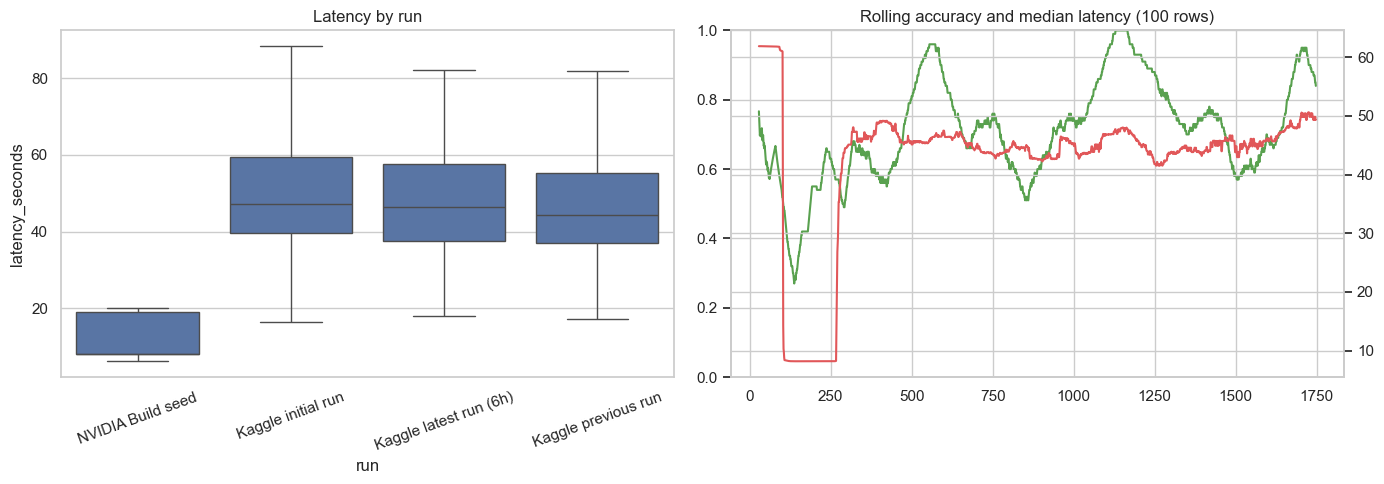

In [9]:
lat=df.groupby('run').latency_seconds.agg(['count','mean','median',lambda s:s.quantile(.95)]).reset_index()
lat.columns=['run','n','mean_s','median_s','p95_s']
display(lat)
fig,axes=plt.subplots(1,2,figsize=(14,5))
sns.boxplot(data=df,x='run',y='latency_seconds',showfliers=False,ax=axes[0]); axes[0].tick_params(axis='x',rotation=20); axes[0].set_title('Latency by run')
ordered=df.sort_values('created_at').copy(); ordered['rolling_accuracy_100']=ordered.correct.rolling(100,min_periods=30).mean()
ordered['rolling_latency_100']=ordered.latency_seconds.rolling(100,min_periods=30).median()
ax2=axes[1].twinx(); axes[1].plot(np.arange(len(ordered)),ordered.rolling_accuracy_100,color='#59A14F',label='accuracy')
ax2.plot(np.arange(len(ordered)),ordered.rolling_latency_100,color='#E15759',label='latency')
axes[1].set_ylim(0,1); axes[1].set_title('Rolling accuracy and median latency (100 rows)')
plt.tight_layout(); plt.show()


## 9. New insights

In [10]:
old=df[df.snapshot.eq('Already in old notebook')]
new=df[df.snapshot.eq('Added after old notebook')]
old_acc=old.correct.mean(); new_acc=new.correct.mean(); all_acc=df.correct.mean()
weak=summarize(df,'question_type').sort_values('accuracy').iloc[0]
latest=df[df.run.eq('Kaggle latest run (6h)')]
new_sources=', '.join(sorted(new.source_dataset.unique()))

text=f'''## What the additional samples changed

- The old executed notebook contained **{len(old):,} successful rows**. The checkpoint pool now contains **{len(df):,}**, adding **{len(new):,} unique successful samples**.
- Accuracy on rows already present in the old notebook is **{old_acc:.1%}**; newly added rows score **{new_acc:.1%}**; the current successful-only aggregate is **{all_acc:.1%}**.
- The additional data covers: **{new_sources}**. Source/task skew still matters; this is not yet a full-MMAD leaderboard score.
- The weakest capability remains **{weak.question_type}** at **{weak.accuracy:.1%}** (n={int(weak.n)}).
- Latest run: **397 successful / 409 attempted**, with **12 parse failures**; operational success yield is **97.1%**.
- Reasoning is present in all successful Kaggle rows, but longer reasoning is not automatically better. The proxy plots above distinguish verbosity, uncertainty language and answer-directed phrasing from actual correctness.
- The main new insight is stronger evidence that Cosmos is good at higher-level defect/object questions but remains weak and conservative on binary anomaly detection. More samples strengthen this pattern rather than overturn it.
'''
display(Markdown(text))


## What the additional samples changed

- The old executed notebook contained **601 successful rows**. The checkpoint pool now contains **1,748**, adding **1,147 unique successful samples**.
- Accuracy on rows already present in the old notebook is **64.6%**; newly added rows score **75.1%**; the current successful-only aggregate is **71.5%**.
- The additional data covers: **MVTec-AD**. Source/task skew still matters; this is not yet a full-MMAD leaderboard score.
- The weakest capability remains **Anomaly Detection** at **44.2%** (n=534).
- Latest run: **397 successful / 409 attempted**, with **12 parse failures**; operational success yield is **97.1%**.
- Reasoning is present in all successful Kaggle rows, but longer reasoning is not automatically better. The proxy plots above distinguish verbosity, uncertainty language and answer-directed phrasing from actual correctness.
- The main new insight is stronger evidence that Cosmos is good at higher-level defect/object questions but remains weak and conservative on binary anomaly detection. More samples strengthen this pattern rather than overturn it.


## 10. Export

In [11]:
out=PRED.parent
run_summary.to_csv(out/'analysis_by_run.csv',index=False)
snapshot_summary.to_csv(out/'analysis_old_vs_new.csv',index=False)
task.to_csv(out/'analysis_by_task.csv',index=False)
source.to_csv(out/'analysis_by_source.csv',index=False)
reason_summary.to_csv(out/'analysis_reasoning.csv',index=False)
report={'audit':AUDIT,'successful_accuracy':float(df.correct.mean()),
        'successful_coverage':float(len(df)/AUDIT['full_benchmark_questions']),
        'old_accuracy':float(old.correct.mean()),'new_accuracy':float(new.correct.mean()),
        'by_run':run_summary.replace({np.nan:None}).to_dict('records'),
        'by_task':task.replace({np.nan:None}).to_dict('records')}
(out/'analysis_summary.json').write_text(json.dumps(report,indent=2,ensure_ascii=False),encoding='utf-8')
print('Saved analysis artifacts to',out)


Saved analysis artifacts to C:\Users\ASUS\OneDrive\Desktop\Jarvis-Vision\research\mmad_model_benchmark\outputs\cosmos3_checkpoint_full
